## Project Description: Hand Gesture Classification Using MediaPipe Landmarks from the HaGRID Dataset



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report
import joblib
import plotly.express as px

Step1: Load Data and exploare it

In [3]:
df_original = pd.read_csv('./data/hand_landmarks_data.csv')

In [4]:
df_original.head()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,262.669968,257.304901,-3.649205e-07,257.417542,247.109055,0.004224,246.882957,241.716827,0.005798,236.384537,...,223.345093,255.490692,-0.020450,215.043365,258.114746,-0.024577,208.006393,259.608673,-0.026722,call
1,83.351778,346.059113,-2.345265e-07,81.925037,328.562347,-0.011102,90.080132,311.535248,-0.021096,95.641823,...,132.451618,341.794434,-0.038175,142.773582,342.829254,-0.037336,152.431698,343.015991,-0.036136,call
2,187.756977,260.235492,-2.417307e-07,195.460579,241.506035,-0.000184,207.259529,223.674339,-0.009687,215.413628,...,250.301010,268.602938,-0.044068,262.425133,271.276638,-0.040469,272.989952,272.272231,-0.038301,call
3,114.976696,331.594238,-1.233261e-07,114.503494,320.549957,-0.002824,116.636627,310.080994,-0.008911,117.685066,...,145.195450,329.357544,-0.027622,151.053200,329.712341,-0.027863,155.990364,329.548828,-0.027723,call
4,188.795288,141.727867,-1.622995e-07,188.520905,127.947464,-0.002884,191.982880,111.010563,-0.008115,192.552521,...,226.696396,132.263248,-0.025113,234.831741,130.684147,-0.024087,241.587769,128.477188,-0.023486,call


In [5]:
df_original.shape

(25675, 64)

Each gesture is represented by a set of hand landmarks (21 landmarks per hand) extracted using MediaPipe. The CSV file will contain these landmarks(x,y,z location) along with their corresponding gesture labels.


In [6]:
df_original.columns

Index(['x1', 'y1', 'z1', 'x2', 'y2', 'z2', 'x3', 'y3', 'z3', 'x4', 'y4', 'z4',
       'x5', 'y5', 'z5', 'x6', 'y6', 'z6', 'x7', 'y7', 'z7', 'x8', 'y8', 'z8',
       'x9', 'y9', 'z9', 'x10', 'y10', 'z10', 'x11', 'y11', 'z11', 'x12',
       'y12', 'z12', 'x13', 'y13', 'z13', 'x14', 'y14', 'z14', 'x15', 'y15',
       'z15', 'x16', 'y16', 'z16', 'x17', 'y17', 'z17', 'x18', 'y18', 'z18',
       'x19', 'y19', 'z19', 'x20', 'y20', 'z20', 'x21', 'y21', 'z21', 'label'],
      dtype='str')

The HaGRID dataset contains 18 classes of hand gestures, including:

In [7]:
df_original['label'].unique()

<StringArray>
[           'call',         'dislike',            'fist',            'four',
            'like',            'mute',              'ok',             'one',
            'palm',           'peace',  'peace_inverted',            'rock',
            'stop',   'stop_inverted',           'three',          'three2',
          'two_up', 'two_up_inverted']
Length: 18, dtype: str

In [8]:
df_original['label'].value_counts()

label
three2             1653
palm               1649
four               1634
ok                 1592
stop_inverted      1567
call               1506
peace_inverted     1497
stop               1482
rock               1458
three              1456
peace              1441
like               1436
two_up_inverted    1371
two_up             1343
dislike            1295
one                1263
mute               1087
fist                945
Name: count, dtype: int64

This mean that the data is unbalanced and when we split we must take care of this by clarifiying the strategy

In [9]:
df_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 25675 entries, 0 to 25674
Data columns (total 64 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      25675 non-null  float64
 1   y1      25675 non-null  float64
 2   z1      25675 non-null  float64
 3   x2      25675 non-null  float64
 4   y2      25675 non-null  float64
 5   z2      25675 non-null  float64
 6   x3      25675 non-null  float64
 7   y3      25675 non-null  float64
 8   z3      25675 non-null  float64
 9   x4      25675 non-null  float64
 10  y4      25675 non-null  float64
 11  z4      25675 non-null  float64
 12  x5      25675 non-null  float64
 13  y5      25675 non-null  float64
 14  z5      25675 non-null  float64
 15  x6      25675 non-null  float64
 16  y6      25675 non-null  float64
 17  z6      25675 non-null  float64
 18  x7      25675 non-null  float64
 19  y7      25675 non-null  float64
 20  z7      25675 non-null  float64
 21  x8      25675 non-null  float64
 22  y8      2

In [10]:
df_original.describe()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,z18,x19,y19,z19,x20,y20,z20,x21,y21,z21
count,25675.000000,25675.000000,2.567500e+04,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,...,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000
mean,201.958632,260.158527,1.272461e-07,202.517395,252.115322,-0.009465,202.862981,240.645966,-0.015946,203.025267,...,-0.024129,201.792374,227.455597,-0.033751,201.811275,227.802576,-0.032208,201.874802,227.807287,-0.028828
std,90.500333,76.533210,2.737932e-07,84.770933,75.384691,0.010376,80.412089,74.721921,0.013973,79.647588,...,0.015658,94.046497,77.231210,0.020453,93.664595,78.441253,0.020877,93.547017,79.963438,0.021136
min,-36.050926,45.722923,-2.029986e-06,7.184681,51.256840,-0.096630,25.114323,45.489950,-0.155846,23.446341,...,-0.201897,0.198635,20.146784,-0.286821,3.278137,32.158108,-0.286470,-4.537216,23.226204,-0.262047
25%,124.110329,205.815950,-5.243216e-08,130.535929,197.999625,-0.015199,136.711035,187.018583,-0.023020,138.905817,...,-0.030728,126.828913,172.720392,-0.042726,126.887403,172.345467,-0.041957,126.356627,172.083794,-0.039220
50%,199.667847,255.181793,1.497277e-07,199.979530,247.113892,-0.008737,200.092758,235.776978,-0.014231,200.482040,...,-0.020969,197.579865,221.781479,-0.029942,197.591736,222.381149,-0.028510,197.453270,222.485229,-0.025269
75%,266.428482,304.991663,2.989988e-07,261.147457,296.850769,-0.002783,255.876354,284.925993,-0.007134,254.622768,...,-0.013661,268.103920,273.190765,-0.019987,267.745743,274.196884,-0.017971,267.324657,275.805222,-0.014294
max,633.556020,781.674469,1.876254e-06,606.232386,751.869416,0.076365,598.541348,719.365010,0.094131,607.999801,...,0.031774,632.923029,779.419948,0.078105,638.134761,760.854103,0.104580,641.788521,760.554894,0.118668


Checking if there is missing values

In [11]:
df_original.isnull().sum()

x1       0
y1       0
z1       0
x2       0
y2       0
        ..
z20      0
x21      0
y21      0
z21      0
label    0
Length: 64, dtype: int64

Split the data and the label

In [12]:
X = df_original.drop('label',axis=1)
y = df_original['label']

In [13]:
print(X.shape)
print(y.shape)

(25675, 63)
(25675,)


Make a function to plot the data th visiualize it 

In [14]:
def visua_hand(sample):
    landmarks = sample.reshape(21, 3)
    x_values = landmarks[:, 0]
    y_values = landmarks[:, 1]
    plt.figure()
    plt.scatter(x_values, y_values)
    plt.gca().invert_yaxis()
    plt.title("Hand Landmarks - Sample ")
    plt.show()


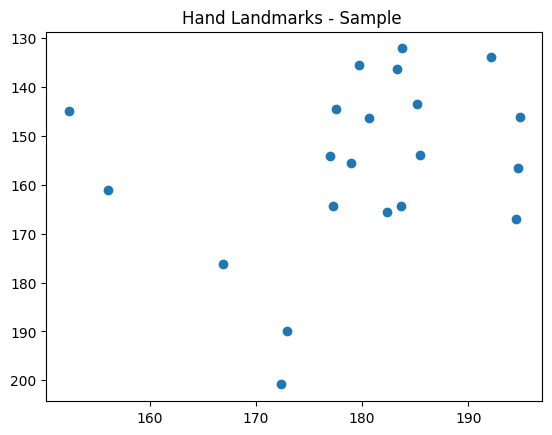

1999    dislike
Name: label, dtype: str

In [15]:
sample = X.iloc[[1999]].values
visua_hand(sample)
y.iloc[[1999]]

Print all clases 

In [16]:
classes = df_original.iloc[:, -1].unique()
print(classes)

<StringArray>
[           'call',         'dislike',            'fist',            'four',
            'like',            'mute',              'ok',             'one',
            'palm',           'peace',  'peace_inverted',            'rock',
            'stop',   'stop_inverted',           'three',          'three2',
          'two_up', 'two_up_inverted']
Length: 18, dtype: str


Visualize some samples of diiferent classes 

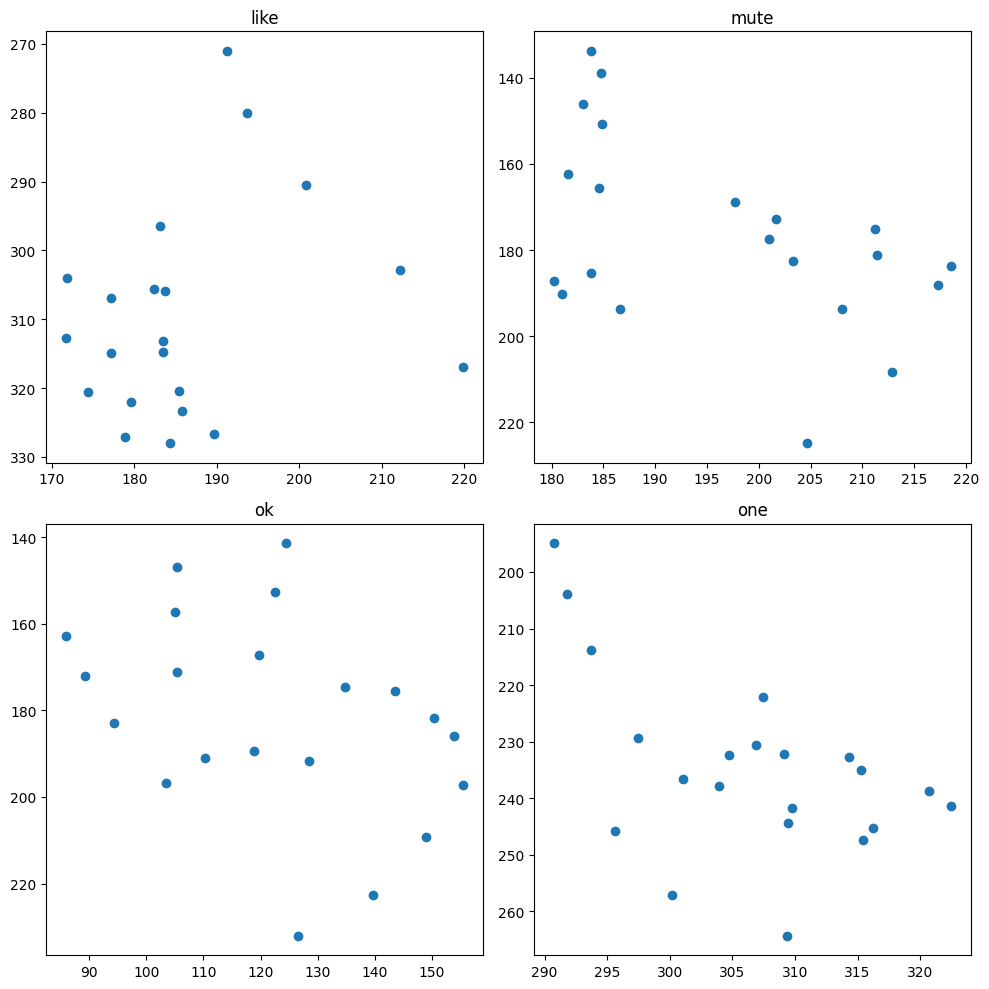

In [17]:
selected_classes = classes[4:8]

plt.figure(figsize=(10, 10))

for i, gesture in enumerate(selected_classes):
    
    # Get one sample of this gesture
    sample_row = df_original[df_original.iloc[:, -1] == gesture].iloc[0, :-1].values
    
    landmarks = sample_row.reshape(21, 3)
    x_values = landmarks[:, 0]
    y_values = landmarks[:, 1]
    
    plt.subplot(2, 2, i+1)
    plt.scatter(x_values, y_values)
    plt.gca().invert_yaxis()
    plt.title(gesture)

plt.tight_layout()
plt.show()

Step2: Geometric normalization (removing translation/scale from the hand itself)

→ subtract wrist (translation invariance)

→ divide by reference length (scale invariance)

In [18]:
def normalize_translation(row):
    landmarks = row.reshape(21, 3)
    
    wrist = landmarks[0]
    
    normalized = landmarks - wrist
    
    return normalized.flatten()


In [19]:
X_normalized = np.apply_along_axis(normalize_translation, 1, X.values)
print(X_normalized.shape)

(25675, 63)


In [20]:
X_normalized

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -5.46635742e+01,  2.30377197e+00, -2.67219973e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         6.90799198e+01, -3.04312134e+00, -3.61355806e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         8.52329750e+01,  1.20367386e+01, -3.83002911e-02],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -1.86668701e+01, -3.62598367e+01, -1.08039489e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         3.06501617e+01, -2.78314819e+01, -2.02772485e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -8.91605389e+00, -2.51958961e+01, -9.86753546e-03]],
      shape=(25675, 63))

Visualize the affect of the normalization

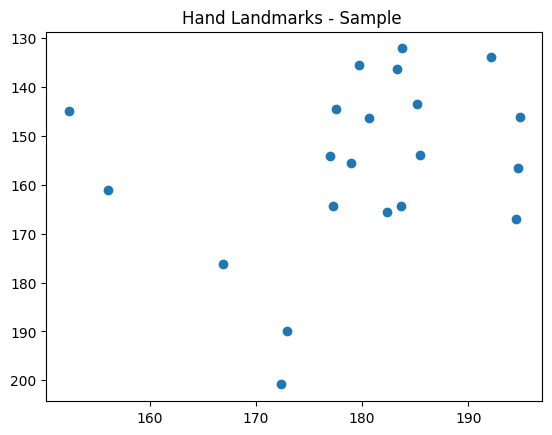

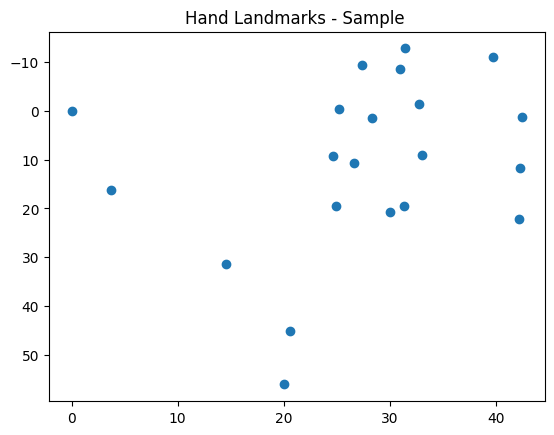

In [21]:
sample = X_normalized[1999]
sample1 = X.iloc[[1999]].values
visua_hand(sample1)
visua_hand(sample)

The datapoints become smaller and have the same range 

Step3: Scale Normalization:

- Pick a reference length. A common choice: distance from wrist (landmark 0) to middle fingertip (landmark 12).

- For each sample, compute this distance.

- Divide all landmarks by this distance.

In [22]:
def normalize_scale(row):
    landmarks = row.reshape(21, 3)
    wrist = landmarks[0]
    middle_tip = landmarks[12]
    
    ref_length = np.linalg.norm(middle_tip - wrist)
    
    normalized = landmarks / ref_length
    return normalized.flatten()

In [23]:
X_normalized_scaled = np.apply_along_axis(normalize_scale, 1, X_normalized)
print(X_normalized_scaled.shape)

(25675, 63)


After this:

- All hands are centered at the wrist

- All hands are roughly the same “size”

- Now the model sees shape only, not position or scale

Visualization of all we have 

Scale and Normalized verion


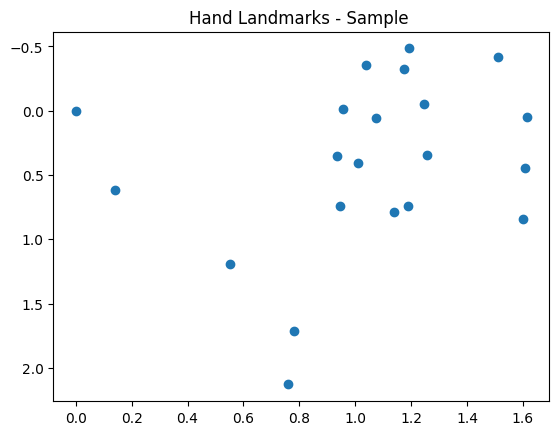

Normalized verion


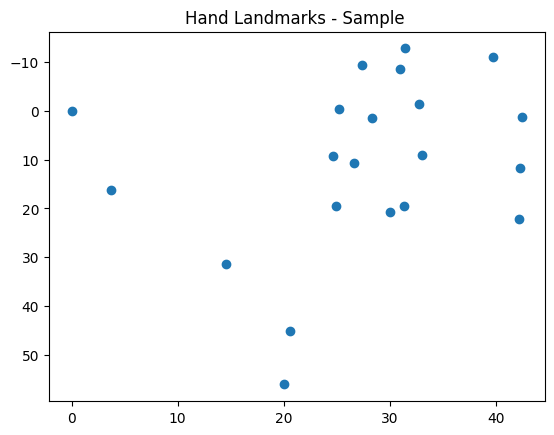

the real sample


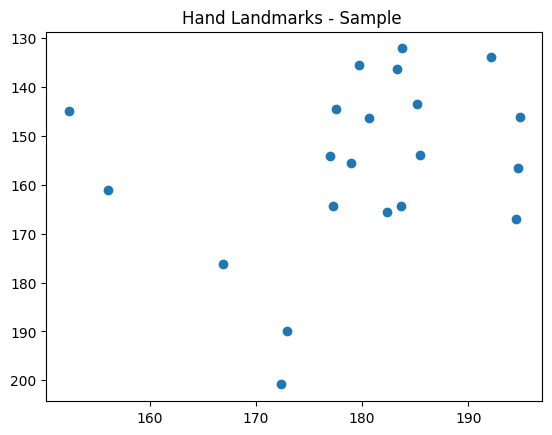

In [24]:
sample = X_normalized_scaled[1999]
print("Scale and Normalized verion")
visua_hand(sample)
sample2 = X_normalized[1999]
sample1 = X.iloc[[1999]].values
print("Normalized verion")
visua_hand(sample2)
print("the real sample")
visua_hand(sample1)

Geometric normalization (what we just did)

- Centers the hand at the wrist

- Makes all hands the same scale

- Preserves the shape information — this is the main signal our model needs to classify gestures

Encode the label column 

In [25]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("First 10 encoded labels:", y_encoded[:10])
print("Classes:", le.classes_)

First 10 encoded labels: [0 0 0 0 0 0 0 0 0 0]
Classes: ['call' 'dislike' 'fist' 'four' 'like' 'mute' 'ok' 'one' 'palm' 'peace'
 'peace_inverted' 'rock' 'stop' 'stop_inverted' 'three' 'three2' 'two_up'
 'two_up_inverted']


In [26]:
print("X shape:", X_normalized_scaled.shape)
print("y shape:", y_encoded.shape)

X shape: (25675, 63)
y shape: (25675,)


Spliting the data to train and test 

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [28]:
print("X train:", X_train.shape)
print("y train:", y_train.shape)
print("X test:", X_test.shape)
print("y test:", y_test.shape)


X train: (20540, 63)
y train: (20540,)
X test: (5135, 63)
y test: (5135,)


Start declare the models we will use to choose one of them

In [29]:
models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=500))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf"))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),

    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42
    )
}


Showing the results of our models 

In [30]:
results = {}

for name, model in models.items():
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    
    results[name] = {
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }
    
    print(f"\n{name}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")



Logistic Regression
Accuracy:  0.9114
Precision: 0.9145
Recall:    0.9139
F1 Score:  0.9138

SVM
Accuracy:  0.9398
Precision: 0.9397
Recall:    0.9398
F1 Score:  0.9394

KNN
Accuracy:  0.9671
Precision: 0.9667
Recall:    0.9673
F1 Score:  0.9667

Random Forest
Accuracy:  0.9762
Precision: 0.9759
Recall:    0.9761
F1 Score:  0.9759


c:\Users\youss\OneDrive\Desktop\Task_ML1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\youss\OneDrive\Desktop\Task_ML1\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [03:35:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



AdaBoost
Accuracy:  0.6045
Precision: 0.5640
Recall:    0.6132
F1 Score:  0.5524

XGBoost
Accuracy:  0.9829
Precision: 0.9829
Recall:    0.9827
F1 Score:  0.9828


From this we can Choose XGBoost as the winner model with high accuracy

In [31]:
final_model = XGBClassifier(
    n_estimators=100,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

# Train on full training data
final_model.fit(X_train, y_train)

c:\Users\youss\OneDrive\Desktop\Task_ML1\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [03:35:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

Confusion Matrix

In [32]:
cm = classification_report(y_test, y_pred, target_names=le.classes_)
print(cm)

                 precision    recall  f1-score   support

           call       0.99      0.99      0.99       301
        dislike       1.00      1.00      1.00       259
           fist       1.00      0.99      1.00       189
           four       0.97      0.99      0.98       327
           like       0.99      1.00      0.99       287
           mute       0.97      0.96      0.97       217
             ok       0.99      0.99      0.99       318
            one       0.96      0.97      0.97       253
           palm       0.98      0.98      0.98       330
          peace       0.97      0.97      0.97       288
 peace_inverted       0.98      0.98      0.98       299
           rock       1.00      0.99      0.99       292
           stop       0.96      0.97      0.97       296
  stop_inverted       0.98      0.98      0.98       314
          three       1.00      0.97      0.98       291
         three2       0.99      0.98      0.99       331
         two_up       0.96    

Plot Confussion Matrix

In [33]:
cm = confusion_matrix(y_test, y_pred)

labels = le.classes_
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

fig = px.imshow(
    cm_df,
    text_auto=True,        # show counts in cells
    color_continuous_scale="Blues",
    labels=dict(x="Predicted", y="Actual", color="Count")
)

fig.update_layout(
    title="Confusion Matrix",
    xaxis=dict(side="top")  # predicted labels at the top
)

fig.show()


Save Our Model

In [34]:
# Save model
joblib.dump(final_model, "xgb_hand_gesture_model.pkl")

# Save label encoder
joblib.dump(le, "label_encoder.pkl")


['label_encoder.pkl']